
# Scripted Trade with Heston

Demonstrate using the Heston model 
- calibration to DAX, STOXX50 and S&P500 options
- pricing: Vanilla Equity Option, Barrier Option, Rainbow Option

Prerequisites:
- Python 3
- pandas, matplotlib
- ORE Python (first 2026 release)

### Run ORE

In [1]:
from ORE import *
import sys, time, math
sys.path.append('..')
import utilities

params = Parameters()
params.fromFile("Input/ore_heston.xml")
#params.fromFile("Input/ore_black.xml")

ore = OREApp(params)
ore.run()

utilities.checkErrorsAndRunTime(ore)

Run time: 3.42 sec
Errors: 0


### NPV report

In [2]:
report = ore.getReport("npv")
utilities.format_report(report)

,TradeId,TradeType,Maturity,MaturityTime,NPV,NpvCurrency,NPV(Base),BaseCurrency,Notional,NotionalCurrency,Notional(Base),NettingSet,CounterParty
0,1:EquityOption,EquityOption,2023-09-05,0.252055,141767.966246,EUR,141767.966246,EUR,4.350000e+06,EUR,4.350000e+06,CPTY,CPTY
1,2:ScriptedEquityOption,ScriptedTrade,2023-09-05,0.252055,141832.132676,EUR,141832.132676,EUR,3.402823e+38,#N/A,3.402823e+38,CPTY,CPTY
2,3:EquityBarrierOption,EquityBarrierOption,2023-09-05,0.252055,96747.366016,EUR,96747.366016,EUR,4.350000e+06,EUR,4.350000e+06,CPTY,CPTY
3,4:ScriptedEquityBarrierOption,ScriptedTrade,2023-09-05,0.252055,131991.994512,EUR,131991.994512,EUR,3.402823e+38,EUR,3.402823e+38,CPTY,CPTY
4,5:RainbowOption-STOXX-DAX,ScriptedTrade,2023-09-05,0.252055,1082.829395,EUR,1082.829395,EUR,4.000000e+03,EUR,4.000000e+03,CPTY,CPTY
5,6:RainbowOption-STOXX-DAX-SPX,ScriptedTrade,2023-09-05,0.252055,1082.790779,EUR,1082.790779,EUR,4.000000e+03,EUR,4.000000e+03,CPTY,CPTY


### Calibration report

In [3]:
import pandas as pd

df = pd.read_csv('Output/assetmodelcalibration.csv')

pd.set_option('display.expand_frame_repr', False)
print(df)

               Index      RMSE Expiry  Moneyness  MarketValue  ModelValue  MarketVol  ModelVol   DiffVol
0      EQ-RIC:.GDAXI  0.000653     3M       -2.0     2.656520    2.795720   0.117504  0.118233 -0.000730
1      EQ-RIC:.GDAXI  0.000653     3M       -1.5    11.041800   10.795200   0.112906  0.112473  0.000433
2      EQ-RIC:.GDAXI  0.000653     3M       -1.0    45.197600   44.731900   0.111753  0.111438  0.000315
3      EQ-RIC:.GDAXI  0.000653     3M       -0.5   172.528000  171.841000   0.121804  0.121554  0.000250
4      EQ-RIC:.GDAXI  0.000653     3M        0.0   452.483000  454.176000   0.141661  0.142191 -0.000530
5      EQ-RIC:.GDAXI  0.000653     3M        0.5   285.420000  286.907000   0.164757  0.165277 -0.000520
6      EQ-RIC:.GDAXI  0.000653     3M        1.0   187.058000  188.204000   0.187031  0.187526 -0.000495
7      EQ-RIC:.GDAXI  0.000653     3M        1.5   127.125000  126.851000   0.208548  0.208396  0.000152
8      EQ-RIC:.GDAXI  0.000653     3M        2.0    89.

### Filter one index and expiry

In [4]:
index = "EQ-RIC:.STOXX50E"
#index = "EQ-RIC:.GDAXI"
#index = "EQ-RIC:.SPX"
expiry = "3M"
df = df[df["Index"] == index]
df = df[df["Expiry"] == expiry]
print(df)

               Index      RMSE Expiry  Moneyness  MarketValue  ModelValue  MarketVol  ModelVol   DiffVol
18  EQ-RIC:.STOXX50E  0.000952     3M       -2.0      1.27794     1.22403   0.131489  0.130742  0.000748
19  EQ-RIC:.STOXX50E  0.000952     3M       -1.5      3.92054     4.20465   0.122890  0.124455 -0.001565
20  EQ-RIC:.STOXX50E  0.000952     3M       -1.0     15.32210    15.16560   0.122897  0.122536  0.000361
21  EQ-RIC:.STOXX50E  0.000952     3M       -0.5     51.95240    51.15710   0.131382  0.130325  0.001057
22  EQ-RIC:.STOXX50E  0.000952     3M        0.0    128.67300   128.55400   0.148379  0.148242  0.000137
23  EQ-RIC:.STOXX50E  0.000952     3M        0.5     78.36640    78.89740   0.169045  0.169733 -0.000687
24  EQ-RIC:.STOXX50E  0.000952     3M        1.0     49.48370    50.13320   0.190075  0.191129 -0.001053
25  EQ-RIC:.STOXX50E  0.000952     3M        1.5     32.47820    32.73540   0.210960  0.211507 -0.000547
26  EQ-RIC:.STOXX50E  0.000952     3M        2.0     22

### Plot smile section

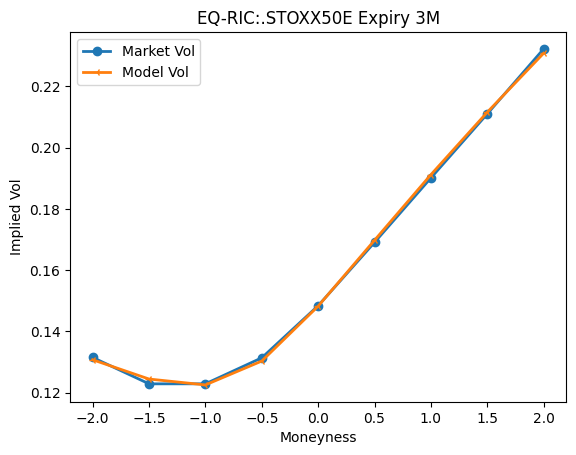

In [5]:
x = df["Moneyness"]
y1 = df["MarketVol"]
y2 = df["ModelVol"]

import matplotlib.pyplot as plt

plt.plot(x, y1, marker="o", linewidth=2, label='Market Vol')
plt.plot(x, y2, marker="3", linewidth=2, label='Model Vol')

plt.xlabel("Moneyness") 
plt.ylabel("Implied Vol") 
plt.title(index + ' Expiry 3M')
plt.legend()

plt.show()